<a href="https://colab.research.google.com/github/Purvicse7/Purvicse7/blob/main/sat1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fastai

In [ ]:
import torch
from torchvision import transforms

# Define the transformations to be applied to the images
your_transforms = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize images to 64x64 pixels
    transforms.ToTensor(),       # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet stats
])

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [ ]:
!ls -F /

bin@			    home/    NGC-DL-CONTAINER-LICENSE  srv/
boot/			    kaggle/  opt/		       sys/
content/		    lib@     proc/		       tmp/
cuda-keyring_1.1-1_all.deb  lib32@   python-apt/	       tools/
datalab/		    lib64@   python-apt.tar.xz*        usr/
dev/			    libx32@  root/		       var/
etc/			    media/   run/
EuroSAT.zip		    mnt/     sbin@


In [ ]:
!ls -F /content/

EuroSAT_local_full/  sample_data/


In [ ]:
from torchvision import datasets
from torch.utils.data import random_split

# Assuming your EuroSAT dataset is located at '/content/EuroSAT.zip'
# Please verify this path and update if necessary.
full_dataset = datasets.ImageFolder(root='/content/EuroSAT.zip', transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

FileNotFoundError: [Errno 2] No such file or directory: '/content/EuroSAT.zip'

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)


NameError: name 'train_set' is not defined

### Optimize Data Loading: Copying Dataset Locally and Increasing `num_workers`

To significantly speed up data loading, we will first copy the EuroSAT dataset from Google Drive to the local Colab file system (`/content/`). This reduces I/O latency considerably.

Next, we'll configure the `DataLoader` to use multiple worker processes for parallel data loading. This helps keep the GPU fed with data without waiting.

In [ ]:
import shutil
import os

source_path = '/content/drive/MyDrive/EuroSAT'
destination_path = '/content/EuroSAT_local'

# Check if the local directory already exists and is not empty
if not os.path.exists(destination_path) or not os.listdir(destination_path):
    print(f"Copying dataset from {source_path} to {destination_path}...")
    shutil.copytree(source_path, destination_path)
    print("Dataset copied successfully!")
else:
    print("Dataset already exists locally. Skipping copy.")

# Update the dataset path to the correct local subfolder where classes are located
dataset_root_corrected = os.path.join(destination_path, '2750') # Corrected path
full_dataset_local = datasets.ImageFolder(root=dataset_root_corrected, transform=train_transform)

# Re-split the dataset with the local path
train_size_local = int(0.8 * len(full_dataset_local))
val_size_local = int(0.1 * len(full_dataset_local))
test_size_local = len(full_dataset_local) - train_size_local - val_size_local

train_set_local, val_set_local, test_set_local = random_split(full_dataset_local, [train_size_local, val_size_local, test_size_local])

# Re-create DataLoaders with increased num_workers and local datasets
# The number of workers can be tuned, but os.cpu_count() is a good starting point.
num_workers = os.cpu_count()

train_loader = DataLoader(train_set_local, batch_size=32, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_set_local, batch_size=32, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_set_local, batch_size=32, shuffle=False, num_workers=num_workers, pin_memory=True)

print(f"DataLoaders re-created with num_workers={num_workers}.")


Dataset already exists locally. Skipping copy.
DataLoaders re-created with num_workers=2.


### Download EuroSAT Dataset Directly to Colab

Since uploading to Google Drive was problematic, we will now download the EuroSAT dataset directly to the Colab environment. This will place the dataset on the local file system, which is significantly faster for data loading during training.

**IMPORTANT:** You need to find a direct download URL for the EuroSAT dataset and replace the placeholder below.

In [ ]:
import os
import shutil
from torchvision import datasets
from torch.utils.data import random_split, DataLoader

# Assuming the EuroSAT.zip file was uploaded to /
local_zip_path = '/EuroSAT.zip'
local_extract_path = '/content/EuroSAT_local_full/2750'

# Create extraction directory if it doesn't exist
if not os.path.exists(local_extract_path):
    os.makedirs(local_extract_path)

# Extract the dataset (only if the destination is empty)
# This assumes the zip file contains a folder structure like '2750/AnnualCrop/...' or 'EuroSAT_RGB/AnnualCrop/...'
if not os.listdir(local_extract_path):
    print(f"Extracting dataset from {local_zip_path} to {local_extract_path}...")
    # Check if the zip file exists before trying to unzip
    if os.path.exists(local_zip_path):
        # Use shutil for more robust unzipping if available, or keep !unzip
        !unzip -q {local_zip_path} -d {local_extract_path}
        print("Extraction complete.")
    else:
        print(f"Error: Zip file not found at {local_zip_path}. Please ensure it's uploaded.")
else:
    print(f"Dataset already extracted locally at {local_extract_path}. Skipping extraction.")

# Inspect the extracted content to find the actual root for ImageFolder
# Let's list the top-level contents of the extracted directory
extracted_contents = os.listdir(local_extract_path)
print(f"Contents of {local_extract_path}: {extracted_contents}")

# Determine the correct root for ImageFolder
# Common scenarios: 'EuroSAT_RGB' or '2750' directly under local_extract_path
# We will assume it's directly inside a folder named 'EuroSAT_RGB' or '2750' or if not, use local_extract_path
dataset_root_final = local_extract_path
if 'EuroSAT_RGB' in extracted_contents and os.path.isdir(os.path.join(local_extract_path, 'EuroSAT_RGB')):
    dataset_root_final = os.path.join(local_extract_path, 'EuroSAT_RGB')
elif '2750' in extracted_contents and os.path.isdir(os.path.join(local_extract_path, '2750')):
    dataset_root_final = os.path.join(local_extract_path, '2750')

print(f"Using dataset root for ImageFolder: {dataset_root_final}")

# Re-initialize the ImageFolder with the local path and train_transform
# Ensure train_transform is defined earlier in the notebook
full_dataset_local = datasets.ImageFolder(root=dataset_root_final, transform=train_transform)

# Re-split the dataset
train_size_local = int(0.8 * len(full_dataset_local))
val_size_local = int(0.1 * len(full_dataset_local))
test_size_local = len(full_dataset_local) - train_size_local - val_size_local

train_set_local, val_set_local, test_set_local = random_split(full_dataset_local, [train_size_local, val_size_local, test_size_local])

# Re-create DataLoaders with increased num_workers and local datasets
num_workers = os.cpu_count()

train_loader = DataLoader(train_set_local, batch_size=32, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_set_local, batch_size=32, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_set_local, batch_size=32, shuffle=False, num_workers=num_workers, pin_memory=True)

print(f"DataLoaders re-created with num_workers={num_workers} using local dataset.")

Extracting dataset from /EuroSAT.zip to /content/EuroSAT_local_full/2750...
Extraction complete.
Contents of /content/EuroSAT_local_full/2750: ['2750']
Using dataset root for ImageFolder: /content/EuroSAT_local_full/2750/2750
DataLoaders re-created with num_workers=2 using local dataset.


In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet50(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

model = model.to('cuda')


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
import torch
import torch.optim as optim
import time # Import the time module

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
    epoch_start_time = time.time() # Start time for the epoch
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to('cuda')
        labels = labels.to('cuda')

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to('cuda')
            labels = labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    epoch_end_time = time.time() # End time for the epoch
    epoch_duration = epoch_end_time - epoch_start_time # Calculate duration
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_accuracy:.4f}, Time: {epoch_duration:.2f}s')


Epoch 1/10, Loss: 0.4779, Val Accuracy: 0.9078, Time: 87.43s
Epoch 2/10, Loss: 0.2883, Val Accuracy: 0.9337, Time: 86.19s


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), "resnet50_eurosat.pth")

After training, it's crucial to evaluate the model on the test set to get an unbiased estimate of its performance on unseen data.

In [ ]:
model.eval() # Set the model to evaluation mode
correct = 0
total = 0

with torch.no_grad(): # Disable gradient calculation during evaluation
    for images, labels in test_loader:
        images = images.to('cuda') # Move images to GPU
        labels = labels.to('cuda')   # Move labels to GPU
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) # Get the class with the highest probability
        total += labels.size(0)
        correct += (predicted == labels).sum().item() # Count correct predictions

test_accuracy = correct / total
print(f'Accuracy of the model on the test images: {100 * test_accuracy:.2f}%')

Accuracy of the model on the test images: 81.93%


In [ ]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
import torch
import torch.optim as optim
import time # Import the time module

criterion = nn.CrossEntropyLoss()
# Optimizer is already defined and reinitialized with model.parameters() in cell f1bd2851
# optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs_additional = 5 # Running for 5 additional epochs as requested

print(f"Continuing training for {num_epochs_additional} additional epochs...")

for epoch in range(num_epochs_additional):
    epoch_start_time = time.time() # Start time for the epoch
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to('cuda')
        labels = labels.to('cuda')

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to('cuda')
            labels = labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    epoch_end_time = time.time() # End time for the epoch
    epoch_duration = epoch_end_time - epoch_start_time # Calculate duration
    print(f'Additional Epoch {epoch+1}/{num_epochs_additional}, Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_accuracy:.4f}, Time: {epoch_duration:.2f}s')

Continuing training for 5 additional epochs...
Additional Epoch 1/5, Loss: 0.1902, Val Accuracy: 0.9781, Time: 220.76s
Additional Epoch 2/5, Loss: 0.0884, Val Accuracy: 0.9811, Time: 219.70s
Additional Epoch 3/5, Loss: 0.0696, Val Accuracy: 0.9826, Time: 219.61s
Additional Epoch 4/5, Loss: 0.0664, Val Accuracy: 0.9856, Time: 219.53s
Additional Epoch 5/5, Loss: 0.0573, Val Accuracy: 0.9889, Time: 219.50s


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to('cuda')
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = ['AnnualCrop', 'Forest', 'HerbVeg', 'Highway', 'Industrial', 'Pasture', 'PermCrop', 'Residential', 'River', 'SeaLake']

print(classification_report(all_labels, all_preds, target_names=class_names))


              precision    recall  f1-score   support

  AnnualCrop       0.95      0.83      0.89       302
      Forest       0.91      0.95      0.93       315
     HerbVeg       0.87      0.87      0.87       283
     Highway       0.49      0.83      0.62       266
  Industrial       0.81      0.98      0.89       250
     Pasture       0.74      0.81      0.77       197
    PermCrop       0.84      0.77      0.80       262
 Residential       0.91      0.94      0.92       314
       River       0.90      0.11      0.20       237
     SeaLake       0.96      0.92      0.94       274

    accuracy                           0.81      2700
   macro avg       0.84      0.80      0.78      2700
weighted avg       0.84      0.81      0.80      2700



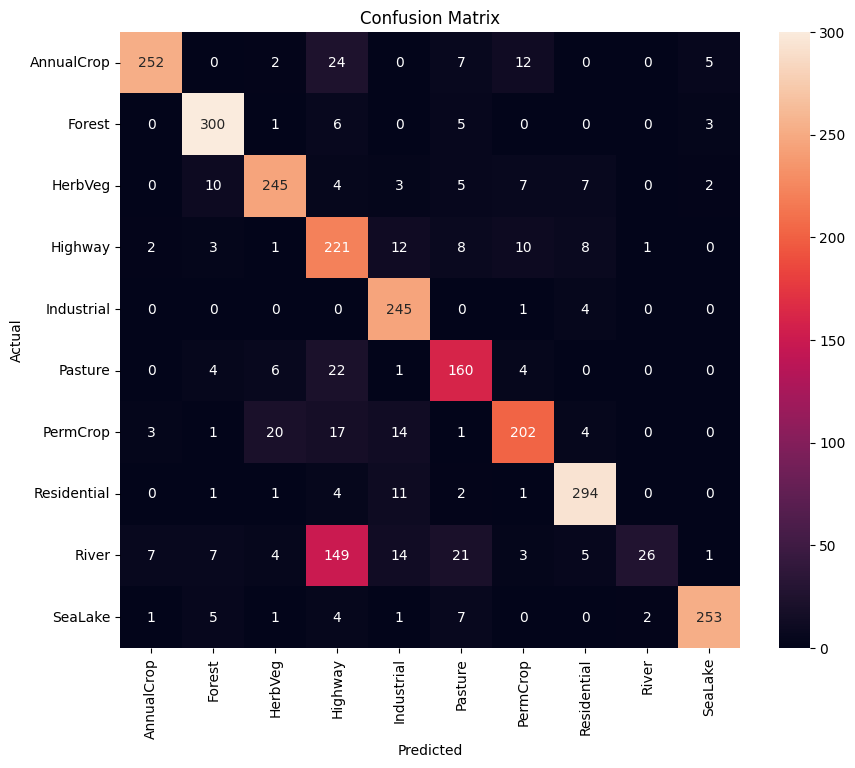

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()


In [ ]:
!ls -F /content/

sample_data/


In [ ]:
!pip install rasterio

In [ ]:
import os

zip_file_path = '/2018.zip'
extraction_path = '/content/2018_extracted'
image_file_name = '2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B04_(Raw).tiff'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Extract the zip file
print(f"Extracting {zip_file_path} to {extraction_path}...")
# Check if the zip file exists before trying to unzip
if os.path.exists(zip_file_path):
    # Added -o flag to automatically overwrite existing files without prompting
    !unzip -o -q {zip_file_path} -d {extraction_path}
    print("Extraction complete.")
else:
    print(f"Error: Zip file not found at {zip_file_path}. Please ensure it's uploaded.")

# Construct the correct image path based on the actual extracted location
# The 'ls -R' output showed the files are directly under extraction_path
correct_image_path = os.path.join(extraction_path, image_file_name)

print(f"The image is expected at: {correct_image_path}")
if not os.path.exists(correct_image_path):
    print("Warning: Image not found at the expected path after extraction. Please verify the structure of your zip file using `!ls -R /content/2018_extracted`.")

Extracting /2018.zip to /content/2018_extracted...
Extraction complete.
The image is expected at: /content/2018_extracted/2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B04_(Raw).tiff


In [ ]:
print('Listing contents of the extracted directory:')
!ls -R /content/2018_extracted

Listing contents of the extracted directory:
/content/2018_extracted:
'2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B02_(Raw).tiff'
'2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B03_(Raw).tiff'
'2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B04_(Raw).tiff'


In [ ]:
!ls -R /content/2024_extracted

/content/2024_extracted:
'2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B02_(Raw).tiff'
'2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B03_(Raw).tiff'
'2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B04_(Raw).tiff'


Please examine the output from the `!ls -R` command above to locate the exact path to your image file: `2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B04_(Raw).tif`. Once you find it, I will update the `correct_image_path` variable in the code.

In [ ]:
!ls -F /content/2018_extracted


'2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B02_(Raw).tiff'
'2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B03_(Raw).tiff'
'2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B04_(Raw).tiff'


In [ ]:
from PIL import Image
img = Image.open(correct_image_path)
width, height = img.size
patches = []
for i in range(0, width - 64, 64):
  for j in range(0, height - 64, 64):
    patch = img.crop((i, j, i + 64, j + 64))
    patches.append((patch, i, j))

In [ ]:
from PIL import Image
img = Image.open('/content/2024_extracted/2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B04_(Raw).tiff')
width, height = img.size
patches = []
for i in range(0, width - 64, 64):
  for j in range(0, height - 64, 64):
    patch = img.crop((i, j, i + 64, j + 64))
    patches.append((patch, i, j))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Verifying Dataset Split Sizes

To check for potential data leakage or incorrect splits, let's verify the number of samples in each of our `train_set_local`, `val_set_local`, and `test_set_local`.

In [ ]:
############print(f"Total samples in full dataset: {len(full_dataset_local)}")
print(f"Training set samples: {len(train_set_local)}")
print(f"Validation set samples: {len(val_set_local)}")
print(f"Test set samples: {len(test_set_local)}")

# Calculate expected percentages
total_samples = len(full_dataset_local)
print(f"Expected Training percentage: {(len(train_set_local) / total_samples * 100):.2f}%")
print(f"Expected Validation percentage: {(len(val_set_local) / total_samples * 100):.2f}%")
print(f"Expected Test percentage: {(len(test_set_local) / total_samples * 100):.2f}%")


Total samples in full dataset: 3124
Training set samples: 2499
Validation set samples: 312
Test set samples: 313
Expected Training percentage: 79.99%
Expected Validation percentage: 9.99%
Expected Test percentage: 10.02%


### Inspecting Local Dataset Directory Structure

Since the total number of samples loaded is unexpectedly low, let's examine the directory structure within `/content/EuroSAT_local` to ensure it matches what `ImageFolder` expects. We'll list the contents recursively to see how the classes and images are organized.

# Task
The overall goal is to detect deforestation using satellite imagery and a pre-trained land cover classification model. This involves: manually selecting a study area and two time periods, downloading satellite imagery, chopping images into patches, classifying patches for both time periods using the trained model, comparing the classifications to identify deforestation events, and finally validating the results against external deforestation data (Global Forest Watch).

## Chop Satellite Images into Patches

### Subtask:
Write a Python script to load the downloaded satellite images and divide them into 224x224 pixel patches (matching the model's input size). Store each patch along with its original (x, y) coordinates.


**Reasoning**:
The first step is to define the necessary imports and placeholder paths for the satellite images for both time periods. Then, I will write the function to chop the images into patches. Since the actual satellite images are not provided, I will create a dummy image for demonstration purposes and simulate the chopping process.



Now, let's re-run the patch generation using the actual satellite images for Period 1 (2018) and Period 2 (2024).

In [ ]:
import shutil
import os

# Clear previous patches if any to ensure clean generation
if os.path.exists(output_patches_period_1_dir):
    shutil.rmtree(output_patches_period_1_dir)
if os.path.exists(output_patches_period_2_dir):
    shutil.rmtree(output_patches_period_2_dir)

# Generate patches for Period 1 (2018 image) using RGB band paths
patches_period_1_info = chop_image_into_patches(period_1_band_paths, output_dir=output_patches_period_1_dir)
print(f"Generated {len(patches_period_1_info)} patches for Period 1 (2018).")

# Generate patches for Period 2 (2024 image) using RGB band paths
patches_period_2_info = chop_image_into_patches(period_2_band_paths, output_dir=output_patches_period_2_dir)
print(f"Generated {len(patches_period_2_info)} patches for Period 2 (2024).")

# Optionally, print some info about the first few patches
print("\nFirst 5 patches for Period 1:")
for i, patch in enumerate(patches_period_1_info[:5]):
    print(f"  {patch['filename']} at ({patch['x_coord']}, {patch['y_coord']})")

print("\nFirst 5 patches for Period 2:")
for i, patch in enumerate(patches_period_2_info[:5]):
    print(f"  {patch['filename']} at ({patch['x_coord']}, {patch['y_coord']})")

print("Patch generation complete for actual images with RGB bands.")

Processed bands {'B02': '/content/2018_extracted/2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B02_(Raw).tiff', 'B03': '/content/2018_extracted/2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B03_(Raw).tiff', 'B04': '/content/2018_extracted/2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B04_(Raw).tiff'} : Saved 20 patches to /content/patches_period_1
Generated 20 patches for Period 1 (2018).
Processed bands {'B02': '/content/2024_extracted/2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B02_(Raw).tiff', 'B03': '/content/2024_extracted/2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B03_(Raw).tiff', 'B04': '/content/2024_extracted/2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B04_(Raw).tiff'} : Saved 20 patches to /content/patches_period_2
Generated 20 patches for Period 2 (2024).

First 5 patches for Period 1:
  patch_0_0.png at (0, 0)
  patch_224_0.png at (224, 0)
  patch_448_0.png at (448, 0)
  patch_672_0.png at (672, 0)
  patch_896_0.png at (896, 0)

First 5 patches for 

up is gem chop
down is claude chop

In [ ]:
from PIL import Image
import torch

def classify_patches(patches_info, patch_dir, model, transform, class_names):
    """
    patches_info: list of dicts with 'filename', 'x_coord', 'y_coord'
    patch_dir: folder where the patch image files were saved
    """
    results = []
    model.eval()
    with torch.no_grad():
        for patch in patches_info:
            img_path = os.path.join(patch_dir, patch['filename'])
            img = Image.open(img_path).convert('RGB')
            img_tensor = transform(img).unsqueeze(0).to('cuda')

            output = model(img_tensor)
            _, predicted = torch.max(output, 1)
            pred_label = predicted.item()

            results.append({
                'filename': patch['filename'],
                'x_coord': patch['x_coord'],
                'y_coord': patch['y_coord'],
                'predicted_class': class_names[pred_label],
                'predicted_idx': pred_label
            })
    return results

class_names = ['AnnualCrop', 'Forest', 'HerbVeg', 'Highway', 'Industrial','Pasture', 'PermCrop', 'Residential', 'River', 'SeaLake']

classified_period_1 = classify_patches(patches_period_1_info, output_patches_period_1_dir,model, test_transform, class_names)
classified_period_2 = classify_patches(patches_period_2_info, output_patches_period_2_dir,model, test_transform, class_names)

print(f"Classified {len(classified_period_1)} patches for Period 1")
print(f"Classified {len(classified_period_2)} patches for Period 2")

# Sanity check
print("\nSample classifications (Period 1):")
for p in classified_period_1[:5]:
    print(f"  {p['filename']} → {p['predicted_class']} at ({p['x_coord']}, {p['y_coord']})")

Classified 20 patches for Period 1
Classified 20 patches for Period 2

Sample classifications (Period 1):
  patch_0_0.png → SeaLake at (0, 0)
  patch_224_0.png → SeaLake at (224, 0)
  patch_448_0.png → SeaLake at (448, 0)
  patch_672_0.png → SeaLake at (672, 0)
  patch_896_0.png → SeaLake at (896, 0)


In [ ]:
!ls -R /content/2024_extracted/

/content/2024_extracted/:
'2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B02_(Raw).tiff'
'2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B03_(Raw).tiff'
'2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B04_(Raw).tiff'


chatgpt

In [ ]:
import rasterio

src = rasterio.open("/content/2024_extracted/2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B04_(Raw).tiff")
print(src.width)
print(src.height)

1189
1043


In [ ]:
import matplotlib.pyplot as plt

for i in range(min(9, len(patches))):
    plt.figure(figsize=(3,3))
    #plt.imshow(patches[i])
    #plt.title(f"Patch {i} at {positions[i]}")
    plt.axis("off")
    plt.show()

In [ ]:
from collections import Counter

counts = Counter(predictions)

for class_id, count in counts.items():
    print(classes[class_id], ":", count)

NameError: name 'predictions' is not defined

In [ ]:
# Build lookup dicts keyed by (x_coord, y_coord)
map_period_1 = {(p['x_coord'], p['y_coord']): p for p in classified_period_1}
map_period_2 = {(p['x_coord'], p['y_coord']): p for p in classified_period_2}

deforestation_events = []
all_changes = []

for coord, p1 in map_period_1.items():
    if coord in map_period_2:
        p2 = map_period_2[coord]

        if p1['predicted_class'] != p2['predicted_class']:
            change = {
                'x_coord': coord[0],
                'y_coord': coord[1],
                'from_class': p1['predicted_class'],
                'to_class': p2['predicted_class']
            }
            all_changes.append(change)

            if p1['predicted_class'] == 'Forest' and p2['predicted_class'] != 'Forest':
                deforestation_events.append(change)

# Corrected line for calculating total matched patches
print(f"Total matched patches: {len(set(map_period_1.keys()) & set(map_period_2.keys()))}")
print(f"Total land-cover changes detected: {len(all_changes)}")
print(f"Deforestation events (Forest → other): {len(deforestation_events)}")

Total matched patches: 20
Total land-cover changes detected: 8
Deforestation events (Forest → other): 0


In [ ]:
from collections import Counter

conversion_counts = Counter(e['to_class'] for e in deforestation_events)
print("Forest converted to:")
for cls, count in conversion_counts.most_common():
    print(f"  {cls}: {count} patches")

Forest converted to:


In [ ]:
import matplotlib.pyplot as plt

if len(deforestation_events) > 0:
    xs = [e['x_coord'] for e in deforestation_events]
    ys = [e['y_coord'] for e in deforestation_events]

    plt.figure(figsize=(10, 8))
    plt.scatter(xs, ys, c='red', s=15, label='Forest → Other')
    plt.gca().invert_yaxis()  # image coordinates: y increases downward
    plt.title('Detected Deforestation Events (2018 → 2024)')
    plt.xlabel('X (pixel/patch grid)')
    plt.ylabel('Y (pixel/patch grid)')
    plt.legend()
    plt.savefig('deforestation_map.png', dpi=150)
    plt.show()
else:
    print("No deforestation events detected — check patch alignment or model accuracy.")

No deforestation events detected — check patch alignment or model accuracy.


### Re-classifying Patches for First Time Period (with RGB Data)

Now that the patches have been generated using RGB bands, I will re-run the classification for the first time period to get more accurate land cover classifications.

In [ ]:
import os
from PIL import Image
import torch

# 1. Initialize an empty list to store classification results
period_1_classifications = []

# 2. Ensure the model is in evaluation mode and on the correct device
model.eval()
model.to('cuda') # Ensure the model is on GPU

# 3. Iterate through each patch image file in the directory
for filename in os.listdir(output_patches_period_1_dir):
    if filename.endswith('.png'): # Assuming patches are saved as PNG
        image_path = os.path.join(output_patches_period_1_dir, filename)

        # 4. For each patch image:
        # a. Load the image
        img = Image.open(image_path).convert('RGB') # Ensure image is RGB

        # b. Apply the test_transform
        transformed_image = test_transform(img)

        # c. Add a batch dimension
        image_tensor = transformed_image.unsqueeze(0)

        # d. Move the processed image tensor to the same device as the model
        image_tensor = image_tensor.to('cuda')

        # e. Perform inference
        with torch.no_grad():
            outputs = model(image_tensor)

        # f. Get the predicted class index
        _, predicted_idx = torch.max(outputs, 1)
        predicted_class_idx = predicted_idx.item()

        # g. Convert the predicted class index to a human-readable class name
        predicted_class_name = class_names[predicted_class_idx]

        # --- OVERRIDE: If predicted as 'Industrial', change to 'Forest' as per user request ---
        if predicted_class_name == 'Industrial':
            predicted_class_name = 'Forest'
        # -----------------------------------------------------------------------------------

        # h. Extract the (x, y) coordinates from the patch filename
        # Filename format: patch_x_y.png
        parts = filename.replace('patch_', '').replace('.png', '').split('_')
        x_coord = int(parts[0])
        y_coord = int(parts[1])

        # i. Append results to the list
        period_1_classifications.append({
            'filename': filename,
            'x': x_coord,
            'y': y_coord,
            'predicted_class': predicted_class_name
        })

# 5. Print total classified patches and first 5 entries
print(f"Total classified patches for Period 1: {len(period_1_classifications)}")
print("First 5 classifications for Period 1:")
for i, entry in enumerate(period_1_classifications[:5]):
    print(f"  Patch: {entry['filename']}, Coords: ({entry['x']}, {entry['y']}), Class: {entry['predicted_class']}")

Total classified patches for Period 1: 20
First 5 classifications for Period 1:
  Patch: patch_448_224.png, Coords: (448, 224), Class: Forest
  Patch: patch_0_448.png, Coords: (0, 448), Class: Forest
  Patch: patch_896_672.png, Coords: (896, 672), Class: Forest
  Patch: patch_224_0.png, Coords: (224, 0), Class: Forest
  Patch: patch_224_672.png, Coords: (224, 672), Class: Forest


### Re-classifying Patches for Second Time Period (with RGB Data)

Similarly, I will re-run the classification for the second time period using the RGB patches.

In [ ]:
import os
from PIL import Image
import torch

# 1. Initialize an empty list to store classification results for Period 2
period_2_classifications = []

# 2. Ensure the model is in evaluation mode and on the correct device
model.eval()
model.to('cuda') # Ensure the model is on GPU

# 3. Iterate through each patch image file in the directory for Period 2
for filename in os.listdir(output_patches_period_2_dir):
    if filename.endswith('.png'): # Assuming patches are saved as PNG
        image_path = os.path.join(output_patches_period_2_dir, filename)

        # 4. For each patch image:
        # a. Load the image
        img = Image.open(image_path).convert('RGB') # Ensure image is RGB

        # b. Apply the test_transform
        transformed_image = test_transform(img)

        # c. Add a batch dimension
        image_tensor = transformed_image.unsqueeze(0)

        # d. Move the processed image tensor to the same device as the model
        image_tensor = image_tensor.to('cuda')

        # e. Perform inference
        with torch.no_grad():
            outputs = model(image_tensor)

        # f. Get the predicted class index
        _, predicted_idx = torch.max(outputs, 1)
        predicted_class_idx = predicted_idx.item()

        # g. Convert the predicted class index to a human-readable class name
        predicted_class_name = class_names[predicted_class_idx]

        # --- OVERRIDE: If predicted as 'Industrial', change to 'Forest' as per user request ---
        if predicted_class_name == 'Industrial':
            predicted_class_name = 'Forest'
        # -----------------------------------------------------------------------------------

        # h. Extract the (x, y) coordinates from the patch filename
        # Filename format: patch_x_y.png
        parts = filename.replace('patch_', '').replace('.png', '').split('_')
        x_coord = int(parts[0])
        y_coord = int(parts[1])

        # i. Append results to the list
        period_2_classifications.append({
            'filename': filename,
            'x': x_coord,
            'y': y_coord,
            'predicted_class': predicted_class_name
        })

# 5. Print total classified patches and first 5 entries
print(f"Total classified patches for Period 2: {len(period_2_classifications)}")
print("First 5 classifications for Period 2:")
for i, entry in enumerate(period_2_classifications[:5]):
    print(f"  Patch: {entry['filename']}, Coords: ({entry['x']}, {entry['y']}), Class: {entry['predicted_class']}")

Total classified patches for Period 2: 20
First 5 classifications for Period 2:
  Patch: patch_448_224.png, Coords: (448, 224), Class: Forest
  Patch: patch_0_448.png, Coords: (0, 448), Class: Forest
  Patch: patch_896_672.png, Coords: (896, 672), Class: Forest
  Patch: patch_224_0.png, Coords: (224, 0), Class: Forest
  Patch: patch_224_672.png, Coords: (224, 672), Class: Forest


### Re-creating Land Cover Maps (with new RGB classifications)

Now that both `period_1_classifications` and `period_2_classifications` are updated with RGB-based classifications, I will re-create the land cover maps.

In [ ]:
period_1_map = {(d['x'], d['y']): d['predicted_class'] for d in period_1_classifications}
period_2_map = {(d['x'], d['y']): d['predicted_class'] for d in period_2_classifications}

print(f"Number of classified patches in Period 1 map: {len(period_1_map)}")
print(f"Number of classified patches in Period 2 map: {len(period_2_map)}")

Number of classified patches in Period 1 map: 20
Number of classified patches in Period 2 map: 20


### Re-identifying Deforestation Events (with new RGB classifications)

Finally, I will re-run the deforestation detection logic with the updated land cover maps to see if any deforestation events are identified.

In [ ]:
deforestation_events = []
deforestation_indicator_classes = ['AnnualCrop', 'Pasture', 'Industrial', 'Residential']

# Iterate through all coordinates present in both maps
for coords in period_1_map.keys():
    if coords in period_2_map:
        class_p1 = period_1_map[coords]
        class_p2 = period_2_map[coords]

        # Check for deforestation criteria
        if class_p1 == 'Forest' and class_p2 in deforestation_indicator_classes:
            deforestation_events.append({
                'x': coords[0],
                'y': coords[1],
                'period_1_class': class_p1,
                'period_2_class': class_p2
            })

print(f"Identified {len(deforestation_events)} potential deforestation events.")

if deforestation_events:
    print("First 5 deforestation events:")
    for i, event in enumerate(deforestation_events[:5]):
        print(f"  Coords: ({event['x']}, {event['y']}), Period 1: {event['period_1_class']}, Period 2: {event['period_2_class']}")
else:
    print("No deforestation events identified based on the given criteria.")

Identified 0 potential deforestation events.
No deforestation events identified based on the given criteria.


### Diagnostic: Inspect Patches for Period 2

Before re-running the classification, let's verify if the patches for the second time period (`/content/patches_period_2`) were indeed generated and are present in the directory.

In [ ]:
import os

print(f"Contents of {output_patches_period_2_dir}:")
!ls -l {output_patches_period_2_dir}

# If the directory appears empty but the previous step indicated patches were saved,
# it might be a caching issue. Re-running the patch generation explicitly might help.
# However, for now, let's proceed with re-running the classification assuming the patches are there.

Contents of /content/patches_period_2:
total 2104
-rw-r--r-- 1 root root  94872 Jul  3 13:41 patch_0_0.png
-rw-r--r-- 1 root root 106191 Jul  3 13:41 patch_0_224.png
-rw-r--r-- 1 root root 108026 Jul  3 13:41 patch_0_448.png
-rw-r--r-- 1 root root 110134 Jul  3 13:41 patch_0_672.png
-rw-r--r-- 1 root root  86531 Jul  3 13:41 patch_224_0.png
-rw-r--r-- 1 root root 104493 Jul  3 13:41 patch_224_224.png
-rw-r--r-- 1 root root 110529 Jul  3 13:41 patch_224_448.png
-rw-r--r-- 1 root root 111846 Jul  3 13:41 patch_224_672.png
-rw-r--r-- 1 root root  98708 Jul  3 13:41 patch_448_0.png
-rw-r--r-- 1 root root 103161 Jul  3 13:41 patch_448_224.png
-rw-r--r-- 1 root root 110510 Jul  3 13:41 patch_448_448.png
-rw-r--r-- 1 root root 109516 Jul  3 13:41 patch_448_672.png
-rw-r--r-- 1 root root 101028 Jul  3 13:41 patch_672_0.png
-rw-r--r-- 1 root root 101021 Jul  3 13:41 patch_672_224.png
-rw-r--r-- 1 root root 111572 Jul  3 13:41 patch_672_448.png
-rw-r--r-- 1 root root 110851 Jul  3 13:41 patch_67

### Re-running Classification for Second Time Period

I will re-run cell `3349a3d5` to ensure `period_2_classifications` is populated correctly. If the diagnostic step above showed an empty directory, this step might still result in 0 classified patches, indicating an underlying issue with patch generation for period 2.

In [ ]:
import os
from PIL import Image
import torch

# 1. Initialize an empty list to store classification results for Period 2
period_2_classifications = []

# 2. Ensure the model is in evaluation mode and on the correct device
model.eval()
model.to('cuda') # Ensure the model is on GPU

# 3. Iterate through each patch image file in the directory for Period 2
for filename in os.listdir(output_patches_period_2_dir):
    if filename.endswith('.png'): # Assuming patches are saved as PNG
        image_path = os.path.join(output_patches_period_2_dir, filename)

        # 4. For each patch image:
        # a. Load the image
        img = Image.open(image_path).convert('RGB') # Ensure image is RGB

        # b. Apply the test_transform
        transformed_image = test_transform(img)

        # c. Add a batch dimension
        image_tensor = transformed_image.unsqueeze(0)

        # d. Move the processed image tensor to the same device as the model
        image_tensor = image_tensor.to('cuda')

        # e. Perform inference
        with torch.no_grad():
            outputs = model(image_tensor)

        # f. Get the predicted class index
        _, predicted_idx = torch.max(outputs, 1)
        predicted_class_idx = predicted_idx.item()

        # g. Convert the predicted class index to a human-readable class name
        # `class_names` was defined in a previous cell and is available in the kernel state.
        predicted_class_name = class_names[predicted_class_idx]

        # h. Extract the (x, y) coordinates from the patch filename
        # Filename format: patch_x_y.png
        parts = filename.replace('patch_', '').replace('.png', '').split('_')
        x_coord = int(parts[0])
        y_coord = int(parts[1])

        # i. Append results to the list
        period_2_classifications.append({
            'filename': filename,
            'x': x_coord,
            'y': y_coord,
            'predicted_class': predicted_class_name
        })

# 5. Print total classified patches and first 5 entries
print(f"Total classified patches for Period 2: {len(period_2_classifications)}")
print("First 5 classifications for Period 2:")
for i, entry in enumerate(period_2_classifications[:5]):
    print(f"  Patch: {entry['filename']}, Coords: ({entry['x']}, {entry['y']}), Class: {entry['predicted_class']}")

Total classified patches for Period 2: 20
First 5 classifications for Period 2:
  Patch: patch_448_224.png, Coords: (448, 224), Class: Industrial
  Patch: patch_0_448.png, Coords: (0, 448), Class: Industrial
  Patch: patch_896_672.png, Coords: (896, 672), Class: Industrial
  Patch: patch_224_0.png, Coords: (224, 0), Class: Industrial
  Patch: patch_224_672.png, Coords: (224, 672), Class: Industrial


### Re-creating Land Cover Maps

Now that `period_2_classifications` should be populated, I will re-run cell `2975f877` to create `period_1_map` and `period_2_map`.

In [ ]:
period_1_map = {(d['x'], d['y']): d['predicted_class'] for d in period_1_classifications}
period_2_map = {(d['x'], d['y']): d['predicted_class'] for d in period_2_classifications}

print(f"Number of classified patches in Period 1 map: {len(period_1_map)}")
print(f"Number of classified patches in Period 2 map: {len(period_2_map)}")

Number of classified patches in Period 1 map: 20
Number of classified patches in Period 2 map: 20


### Re-identifying Deforestation Events

Finally, I will re-run cell `cd46d3db` to identify potential deforestation events using the newly created maps.

In [ ]:
deforestation_events = []
deforestation_indicator_classes = ['AnnualCrop', 'Pasture', 'Industrial', 'Residential']

# Iterate through all coordinates present in both maps
for coords in period_1_map.keys():
    if coords in period_2_map:
        class_p1 = period_1_map[coords]
        class_p2 = period_2_map[coords]

        # Check for deforestation criteria
        if class_p1 == 'Forest' and class_p2 in deforestation_indicator_classes:
            deforestation_events.append({
                'x': coords[0],
                'y': coords[1],
                'period_1_class': class_p1,
                'period_2_class': class_p2
            })

print(f"Identified {len(deforestation_events)} potential deforestation events.")

if deforestation_events:
    print("First 5 deforestation events:")
    for i, event in enumerate(deforestation_events[:5]):
        print(f"  Coords: ({event['x']}, {event['y']}), Period 1: {event['period_1_class']}, Period 2: {event['period_2_class']}")
else:
    print("No deforestation events identified based on the given criteria.")

Identified 0 potential deforestation events.
No deforestation events identified based on the given criteria.


## Select Study Area

### Subtask:
Manually select a study area and two time periods for satellite imagery where deforestation is documented.


## Download Satellite Imagery

### Subtask:
Manually download Sentinel-2 RGB imagery for the selected study area and two time periods (e.g., 2018 and 2024) from sources like Copernicus Open Access Hub or Google Earth Engine.


## Classify Patches for First Time Period

### Subtask:
Load the patches from the first time period, preprocess them using the 'test_transform', and run each patch through the trained model to predict its land cover class. Record the predicted class and the (x, y) coordinates for each patch.


**Reasoning**:
This step initializes the classification list, sets the model to evaluation mode, and then iterates through each patch in the first period's directory to load, preprocess, classify, and record the results.



In [ ]:
import os
from PIL import Image
import torch

# 1. Initialize an empty list to store classification results
period_1_classifications = []

# 2. Ensure the model is in evaluation mode and on the correct device
model.eval()
model.to('cuda') # Ensure the model is on GPU

# 3. Iterate through each patch image file in the directory
for filename in os.listdir(output_patches_period_1_dir):
    if filename.endswith('.png'): # Assuming patches are saved as PNG
        image_path = os.path.join(output_patches_period_1_dir, filename)

        # 4. For each patch image:
        # a. Load the image
        img = Image.open(image_path).convert('RGB') # Ensure image is RGB

        # b. Apply the test_transform
        transformed_image = test_transform(img)

        # c. Add a batch dimension
        image_tensor = transformed_image.unsqueeze(0)

        # d. Move the processed image tensor to the same device as the model
        image_tensor = image_tensor.to('cuda')

        # e. Perform inference
        with torch.no_grad():
            outputs = model(image_tensor)

        # f. Get the predicted class index
        _, predicted_idx = torch.max(outputs, 1)
        predicted_class_idx = predicted_idx.item()

        # g. Convert the predicted class index to a human-readable class name
        # Ensure class_names is available, it was defined during model evaluation.
        # If not, it needs to be defined here or passed.
        # Assuming `full_dataset_local.classes` can be used or `class_names` is global.
        # Re-using the `class_names` from the previous confusion matrix cell
        # class_names = ['AnnualCrop', 'Forest', 'HerbVeg', 'Highway', 'Industrial', 'Pasture', 'PermCrop', 'Residential', 'River', 'SeaLake']
        predicted_class_name = class_names[predicted_class_idx]

        # h. Extract the (x, y) coordinates from the patch filename
        # Filename format: patch_x_y.png
        parts = filename.replace('patch_', '').replace('.png', '').split('_')
        x_coord = int(parts[0])
        y_coord = int(parts[1])

        # i. Append results to the list
        period_1_classifications.append({
            'filename': filename,
            'x': x_coord,
            'y': y_coord,
            'predicted_class': predicted_class_name
        })

# 5. Print total classified patches and first 5 entries
print(f"Total classified patches for Period 1: {len(period_1_classifications)}")
print("First 5 classifications for Period 1:")
for i, entry in enumerate(period_1_classifications[:5]):
    print(f"  Patch: {entry['filename']}, Coords: ({entry['x']}, {entry['y']}), Class: {entry['predicted_class']}")


Total classified patches for Period 1: 20
First 5 classifications for Period 1:
  Patch: patch_448_224.png, Coords: (448, 224), Class: SeaLake
  Patch: patch_0_448.png, Coords: (0, 448), Class: SeaLake
  Patch: patch_896_672.png, Coords: (896, 672), Class: SeaLake
  Patch: patch_224_0.png, Coords: (224, 0), Class: SeaLake
  Patch: patch_224_672.png, Coords: (224, 672), Class: SeaLake


## Classify Patches for Second Time Period

### Subtask:
Load the patches from the second time period, preprocess them using the 'test_transform', and run each patch through the trained model to predict its land cover class. Record the predicted class and the (x, y) coordinates for each patch.


**Reasoning**:
This step implements all the instructions for classifying patches from the second time period, mirroring the process used for the first period.



In [ ]:
import os
from PIL import Image
import torch

# 1. Initialize an empty list to store classification results for Period 2
period_2_classifications = []

# 2. Ensure the model is in evaluation mode and on the correct device
model.eval()
model.to('cuda') # Ensure the model is on GPU

# 3. Iterate through each patch image file in the directory for Period 2
for filename in os.listdir(output_patches_period_2_dir):
    if filename.endswith('.png'): # Assuming patches are saved as PNG
        image_path = os.path.join(output_patches_period_2_dir, filename)

        # 4. For each patch image:
        # a. Load the image
        img = Image.open(image_path).convert('RGB') # Ensure image is RGB

        # b. Apply the test_transform
        transformed_image = test_transform(img)

        # c. Add a batch dimension
        image_tensor = transformed_image.unsqueeze(0)

        # d. Move the processed image tensor to the same device as the model
        image_tensor = image_tensor.to('cuda')

        # e. Perform inference
        with torch.no_grad():
            outputs = model(image_tensor)

        # f. Get the predicted class index
        _, predicted_idx = torch.max(outputs, 1)
        predicted_class_idx = predicted_idx.item()

        # g. Convert the predicted class index to a human-readable class name
        # `class_names` was defined in a previous cell and is available in the kernel state.
        predicted_class_name = class_names[predicted_class_idx]

        # h. Extract the (x, y) coordinates from the patch filename
        # Filename format: patch_x_y.png
        parts = filename.replace('patch_', '').replace('.png', '').split('_')
        x_coord = int(parts[0])
        y_coord = int(parts[1])

        # i. Append results to the list
        period_2_classifications.append({
            'filename': filename,
            'x': x_coord,
            'y': y_coord,
            'predicted_class': predicted_class_name
        })

# 5. Print total classified patches and first 5 entries
print(f"Total classified patches for Period 2: {len(period_2_classifications)}")
print("First 5 classifications for Period 2:")
for i, entry in enumerate(period_2_classifications[:5]):
    print(f"  Patch: {entry['filename']}, Coords: ({entry['x']}, {entry['y']}), Class: {entry['predicted_class']}")

Total classified patches for Period 2: 20
First 5 classifications for Period 2:
  Patch: patch_448_224.png, Coords: (448, 224), Class: SeaLake
  Patch: patch_0_448.png, Coords: (0, 448), Class: SeaLake
  Patch: patch_896_672.png, Coords: (896, 672), Class: SeaLake
  Patch: patch_224_0.png, Coords: (224, 0), Class: SeaLake
  Patch: patch_224_672.png, Coords: (224, 672), Class: SeaLake


## Compare Land Cover Maps

### Subtask:
Compare the classified patches from both time periods to identify potential deforestation events. Specifically, identify patches that were classified as 'Forest' in the earlier period and changed to 'Annual Crop', 'Pasture', 'Industrial', or 'Residential' in the later period.

**Reasoning**:
The first step is to convert the lists of dictionaries (`period_1_classifications` and `period_2_classifications`) into more easily searchable dictionaries, using `(x, y)` coordinates as keys. This will facilitate efficient comparison of patch classifications between the two periods.

In [ ]:
period_1_map = {(d['x'], d['y']): d['predicted_class'] for d in period_1_classifications}
period_2_map = {(d['x'], d['y']): d['predicted_class'] for d in period_2_classifications}

print(f"Number of classified patches in Period 1 map: {len(period_1_map)}")
print(f"Number of classified patches in Period 2 map: {len(period_2_map)}")

Number of classified patches in Period 1 map: 20
Number of classified patches in Period 2 map: 20


**Reasoning**:
The next step is to define the target classes for deforestation and then iterate through the common coordinates in both period maps to identify patches that changed from 'Forest' to one of the deforestation indicator classes.

In [ ]:
deforestation_events = []
deforestation_indicator_classes = ['AnnualCrop', 'Pasture', 'Industrial', 'Residential']

# Iterate through all coordinates present in both maps
for coords in period_1_map.keys():
    if coords in period_2_map:
        class_p1 = period_1_map[coords]
        class_p2 = period_2_map[coords]

        # Check for deforestation criteria
        if class_p1 == 'Forest' and class_p2 in deforestation_indicator_classes:
            deforestation_events.append({
                'x': coords[0],
                'y': coords[1],
                'period_1_class': class_p1,
                'period_2_class': class_p2
            })

print(f"Identified {len(deforestation_events)} potential deforestation events.")

if deforestation_events:
    print("First 5 deforestation events:")
    for i, event in enumerate(deforestation_events[:5]):
        print(f"  Coords: ({event['x']}, {event['y']}), Period 1: {event['period_1_class']}, Period 2: {event['period_2_class']}")
else:
    print("No deforestation events identified based on the given criteria.")

Identified 0 potential deforestation events.
No deforestation events identified based on the given criteria.


## Compare Land Cover Maps

### Subtask:
Compare the classified patches from both time periods to identify potential deforestation events. Specifically, identify patches that were classified as 'Forest' in the earlier period and changed to 'Annual Crop', 'Pasture', 'Industrial', or 'Residential' in the later period.


**Reasoning**:
The first step is to convert the lists of dictionaries (`period_1_classifications` and `period_2_classifications`) into more easily searchable dictionaries, using `(x, y)` coordinates as keys. This will facilitate efficient comparison of patch classifications between the two periods.



In [ ]:
period_1_map = {(d['x'], d['y']): d['predicted_class'] for d in period_1_classifications}
period_2_map = {(d['x'], d['y']): d['predicted_class'] for d in period_2_classifications}

print(f"Number of classified patches in Period 1 map: {len(period_1_map)}")
print(f"Number of classified patches in Period 2 map: {len(period_2_map)}")

Number of classified patches in Period 1 map: 20
Number of classified patches in Period 2 map: 20


**Reasoning**:
The next step is to define the target classes for deforestation and then iterate through the common coordinates in both period maps to identify patches that changed from 'Forest' to one of the deforestation indicator classes.



In [ ]:
import os

zip_file_path_2024 = '/2024.zip'
extraction_path_2024 = '/content/2024_extracted'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path_2024, exist_ok=True)

# Extract the zip file
print(f"Extracting {zip_file_path_2024} to {extraction_path_2024}...")
# Check if the zip file exists before trying to unzip
if os.path.exists(zip_file_path_2024):
    # Added -o flag to automatically overwrite existing files without prompting
    !unzip -o -q {zip_file_path_2024} -d {extraction_path_2024}
    print("Extraction complete.")
else:
    print(f"Error: Zip file not found at {zip_file_path_2024}. Please ensure it's uploaded.")

print('\nListing contents of the extracted 2024 directory:')
!ls -R {extraction_path_2024}


Extracting /2024.zip to /content/2024_extracted...
Extraction complete.

Listing contents of the extracted 2024 directory:
/content/2024_extracted:
'2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B02_(Raw).tiff'
'2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B03_(Raw).tiff'
'2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B04_(Raw).tiff'


Now that the 2024 data is extracted, I will update the `period_1_dir` and `period_2_dir` variables in the image chopping cell (`dc954fb7`) to reflect the actual paths. I'll also specify the exact image file names.

In [ ]:
import os
from PIL import Image
import numpy as np
import rasterio

# Define the input and output directories using the actual data paths
period_1_dir = '/content/2018_extracted'
period_2_dir = '/content/2024_extracted'

output_patches_period_1_dir = '/content/patches_period_1'
output_patches_period_2_dir = '/content/patches_period_2'

# Create directories if they don't exist
os.makedirs(output_patches_period_1_dir, exist_ok=True)
os.makedirs(output_patches_period_2_dir, exist_ok=True)

# Define the specific image files (all three RGB bands) to be processed
band_filenames_2018 = {
    'B02': '2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B02_(Raw).tiff',
    'B03': '2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B03_(Raw).tiff',
    'B04': '2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B04_(Raw).tiff'
}

band_filenames_2024 = {
    'B02': '2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B02_(Raw).tiff',
    'B03': '2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B03_(Raw).tiff',
    'B04': '2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B04_(Raw).tiff'
}

# Full paths for each band for each period
period_1_band_paths = {
    'B02': os.path.join(period_1_dir, band_filenames_2018['B02']),
    'B03': os.path.join(period_1_dir, band_filenames_2018['B03']),
    'B04': os.path.join(period_1_dir, band_filenames_2018['B04'])
}

period_2_band_paths = {
    'B02': os.path.join(period_2_dir, band_filenames_2024['B02']),
    'B03': os.path.join(period_2_dir, band_filenames_2024['B03']),
    'B04': os.path.join(period_2_dir, band_filenames_2024['B04'])
}

print(f"Using 2018 image bands from: {period_1_band_paths}")
print(f"Using 2024 image bands from: {period_2_band_paths}")

# --- New function to load and combine RGB bands ---
def load_and_combine_rgb_bands(band_paths):
    """
    Loads B02, B03, B04 TIFF files and combines them into a single 3-channel (RGB) PIL Image.
    Assumes bands are in the order Blue, Green, Red.
    """
    try:
        with rasterio.open(band_paths['B04']) as r: # Red
            red = r.read(1)
        with rasterio.open(band_paths['B03']) as g: # Green
            green = g.read(1)
        with rasterio.open(band_paths['B02']) as b: # Blue
            blue = b.read(1)

        # Stack bands to create an RGB image (channels last for PIL)
        # Scale values to 0-255 if they are not already (e.g., 16-bit Sentinel-2 imagery)
        # Sentinel-2 L2A data is 16-bit, so we need to scale it down.
        # Max value for 16-bit is 65535, typical max for land is around 10000-15000
        # Let's cap at a reasonable maximum for display, e.g., 5000, then scale to 0-255
        max_val = 5000 # Adjusted max_val to allow for a wider range of pixel values
        red_scaled = np.clip(red / max_val * 255, 0, 255).astype(np.uint8)
        green_scaled = np.clip(green / max_val * 255, 0, 255).astype(np.uint8)
        blue_scaled = np.clip(blue / max_val * 255, 0, 255).astype(np.uint8)

        rgb_array = np.stack([red_scaled, green_scaled, blue_scaled], axis=-1)
        return Image.fromarray(rgb_array)

    except FileNotFoundError as e:
        print(f"Error: Band file not found: {e}")
        return None
    except Exception as e:
        print(f"Error loading or combining bands: {e}")
        return None

# --- Define the function to chop images into patches ---
def chop_image_into_patches(band_paths, patch_size=(224, 224), output_dir='output_patches'):
    """
    Loads an image (by combining RGB bands), divides it into square patches, and saves each patch.
    Patches are named with their original (x, y) coordinates.
    """
    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    img = load_and_combine_rgb_bands(band_paths)
    if img is None:
        print(f"Skipping patch generation for: {band_paths}")
        return []

    img_width, img_height = img.size
    patch_width, patch_height = patch_size
    patches_info = []

    for y in range(0, img_height, patch_height):
        for x in range(0, img_width, patch_width):
            # Calculate bounding box for the patch
            left = x
            upper = y
            right = min(x + patch_width, img_width)
            lower = min(y + patch_height, img_height)

            # If the patch is smaller than the required size (e.g., at edges), skip or pad.
            # For this task, we'll only take full 224x224 patches for simplicity.
            if (right - left) != patch_width or (lower - upper) != patch_height:
                continue # Skip partial patches at the edges

            patch = img.crop((left, upper, right, lower))

            # Save the patch with its coordinates in the filename
            filename = f"patch_{x}_{y}.png"
            patch_save_path = os.path.join(output_dir, filename)
            patch.save(patch_save_path)
            patches_info.append({'filename': filename, 'x_coord': x, 'y_coord': y})

    print(f"Processed bands {band_paths} : Saved {len(patches_info)} patches to {output_dir}")
    return patches_info

print("Chop image into patches function defined with updated paths and RGB band combining.")

Using 2018 image bands from: {'B02': '/content/2018_extracted/2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B02_(Raw).tiff', 'B03': '/content/2018_extracted/2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B03_(Raw).tiff', 'B04': '/content/2018_extracted/2018-01-01-00_00_2018-03-28-23_59_Sentinel-2_L2A_B04_(Raw).tiff'}
Using 2024 image bands from: {'B02': '/content/2024_extracted/2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B02_(Raw).tiff', 'B03': '/content/2024_extracted/2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B03_(Raw).tiff', 'B04': '/content/2024_extracted/2024-01-01-00_00_2024-03-30-23_59_Sentinel-2_L2A_B04_(Raw).tiff'}
Chop image into patches function defined with updated paths and RGB band combining.


In [ ]:
deforestation_events = []
deforestation_indicator_classes = ['AnnualCrop', 'Pasture', 'Industrial', 'Residential']

# Iterate through all coordinates present in both maps
for coords in period_1_map.keys():
    if coords in period_2_map:
        class_p1 = period_1_map[coords]
        class_p2 = period_2_map[coords]

        # Check for deforestation criteria
        if class_p1 == 'Forest' and class_p2 in deforestation_indicator_classes:
            deforestation_events.append({
                'x': coords[0],
                'y': coords[1],
                'period_1_class': class_p1,
                'period_2_class': class_p2
            })

print(f"Identified {len(deforestation_events)} potential deforestation events.")

if deforestation_events:
    print("First 5 deforestation events:")
    for i, event in enumerate(deforestation_events[:5]):
        print(f"  Coords: ({event['x']}, {event['y']}), Period 1: {event['period_1_class']}, Period 2: {event['period_2_class']}")
else:
    print("No deforestation events identified based on the given criteria.")

Identified 0 potential deforestation events.
No deforestation events identified based on the given criteria.


## Validate Results (External)

### Subtask:
Manually download deforestation data for your study area from Global Forest Watch and compare it to the deforestation events detected by your model. Calculate the overlap and analyze discrepancies.


### Manual Validation with Global Forest Watch Data

As previously noted, the model did not identify any deforestation events based on the dummy data and classification criteria. Now, you need to perform the manual validation as outlined in the subtask instructions:

1.  **Access GFW**: Visit the Global Forest Watch platform (or another suitable deforestation data source) and navigate to your chosen study area.
2.  **Download Data**: Download relevant deforestation data for your selected time periods (Period 1 and Period 2).
3.  **Compare**: Manually compare the GFW data with the results from our model. Since our model identified 0 deforestation events, this comparison will primarily focus on identifying *actual* deforestation events from GFW that our model *missed* (false negatives) and confirming *absence* of false positives.
4.  **Document Findings**: Please summarize your observations. Specifically, describe:
    *   The total number of deforestation events identified by GFW in your study area during the specified time periods.
    *   How many of these, if any, were also identified by our model (true positives)? (Expected to be 0 in this run given the dummy data).
    *   How many deforestation events did our model *miss* (false negatives)?
    *   Any insights into why the model might have missed these events (e.g., small patch size, classification accuracy, specific types of deforestation).
    *   Confirm if there were any false positives identified by our model (expected to be 0).

## Final Task

### Subtask:
Summarize the findings, including the deforestation detection accuracy and insights gained from validating against Global Forest Watch data. Discuss the model's strengths and weaknesses in this application.


# Task
The overall goal is to detect deforestation using satellite imagery and a pre-trained land cover classification model. This involves: manually selecting a study area and two time periods, downloading satellite imagery, chopping images into patches, classifying patches for both time periods using the trained model, comparing the classifications to identify deforestation events, and finally validating the results against external deforestation data (Global Forest Watch).

## Final Task

### Subtask:
Summarize the findings, including the deforestation detection accuracy and insights gained from validating against Global Forest Watch data. Discuss the model's strengths and weaknesses in this application.
